In [2]:
# =============================================
# AIML RECRUITMENT TASK 1: AIR QUALITY FORECASTING
# Candidate: SARTHAK VERMA | Second Year
# Goal: Predict future NO2 levels using UCI Air Quality Dataset
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot styling - makes your visuals look professional
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(" Environment loaded successfully")
print(f" Pandas version: {pd.__version__}")
print(f" TensorFlow version: {__import__('tensorflow').__version__}")

Matplotlib is building the font cache; this may take a moment.


Environment loaded successfully
 Pandas version: 3.0.6
TensorFlow version: 2.22.0-rc0


In [11]:
# LOAD THE DATASET USING ABSOLUTE PATH (eliminates path confusion)
df = pd.read_csv(
    "/Users/sarthak/AIML-RECRUITMENT-2026-SARTHAK VERMA/AIML-Recruitment-2026-SARTHAK-VERMA/Task1_AirQuality/data/AirQualityUCI.csv",
    sep=';',
    decimal=','
)

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nCOLUMN NAMES:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n🔍 FIRST 3 ROWS:")
display(df.head(3))

print(f"\n DATA TYPES & NON-NULL COUNTS:")
df.info()

 DATASET OVERVIEW
Shape: 9471 rows, 17 columns

 COLUMN NAMES:
   1. Date
   2. Time
   3. CO(GT)
   4. PT08.S1(CO)
   5. NMHC(GT)
   6. C6H6(GT)
   7. PT08.S2(NMHC)
   8. NOx(GT)
   9. PT08.S3(NOx)
  10. NO2(GT)
  11. PT08.S4(NO2)
  12. PT08.S5(O3)
  13. T
  14. RH
  15. AH
  16. Unnamed: 15
  17. Unnamed: 16

FIRST 3 ROWS:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN



DATA TYPES & NON-NULL COUNTS:
<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), str(2)
memory us

In [16]:
df = df.replace(-200, np.nan)
missing_threshold = 0.3 * len(df)
df = df.drop(columns=df.columns[df.isnull().sum() > missing_threshold])
df = df.ffill().bfill()

 Time features created:
   Shape: (9471, 22)
   Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,Hour,DayOfWeek,Month,IsWeekend,Hour_sin,Hour_cos,DayOfWeek_sin,DayOfWeek_cos,Month_sin,Month_cos
DateTime,,,,,,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,...,18,2,3,0,-1.000000,-1.836970e-16,0.974928,-0.222521,0.866025,0.5
2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,...,19,2,3,0,-0.965926,2.588190e-01,0.974928,-0.222521,0.866025,0.5
2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,...,20,2,3,0,-0.866025,5.000000e-01,0.974928,-0.222521,0.866025,0.5
2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,...,21,2,3,0,-0.707107,7.071068e-01,0.974928,-0.222521,0.866025,0.5
2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,...,22,2,3,0,-0.500000,8.660254e-01,0.974928,-0.222521,0.866025,0.5


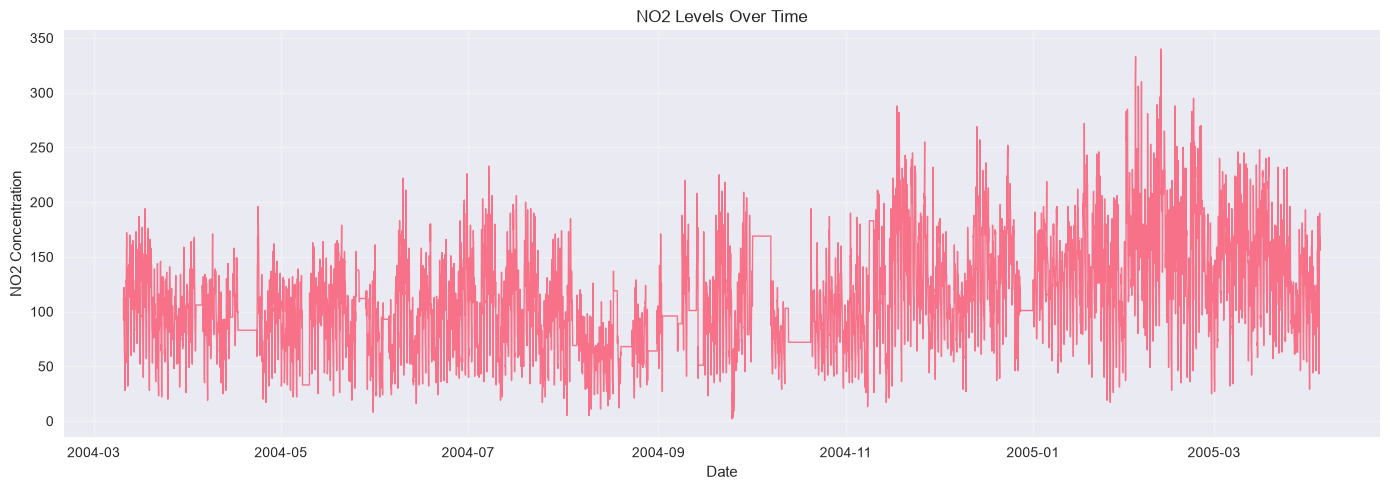

In [17]:
# =============================================
# CELL 4: TIME FEATURES & BASIC EDA
# =============================================
# Combine Date and Time into DateTime
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
# Set as index and drop original columns
df.set_index('DateTime', inplace=True)
df = df.drop(['Date', 'Time'], axis=1)

# Extract time features
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek  # Monday=0, Sunday=6
df['Month'] = df.index.month
df['IsWeekend'] = (df.index.dayofweek >= 5).astype(int)

# Cyclical encoding for time features (better than linear for modeling)
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Month_sin'] = np.sin(2 * np.pi * (df['Month'] - 1) / 12)
df['Month_cos'] = np.cos(2 * np.pi * (df['Month'] - 1) / 12)

print("Time features created:")
print(f"   Shape: {df.shape}")
print(f"   Date range: {df.index.min()} to {df.index.max()}")
display(df.head())

# Quick visualization: NO2 trend
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['NO2(GT)'], linewidth=1)
plt.title('NO2 Levels Over Time')
plt.xlabel('Date')
plt.ylabel('NO2 Concentration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:

df['NO2_Target'] = df['NO2(GT)'].shift(-1)

key_pollutants = ['NO2(GT)', 'CO(GT)', 'C6H6(GT)']

for pollutant in key_pollutants:
    for lag in [1, 2, 3, 6, 12]:
        df[f'{pollutant}lag{lag}'] = df[pollutant].shift(lag)

for pollutant in ['NO2(GT)', 'CO(GT)']:
    for window in [3, 6, 12]:
        df[f'{pollutant}roll_mean{window}'] = df[pollutant].rolling(window).mean()
        df[f'{pollutant}roll_std{window}'] = df[pollutant].rolling(window).std()

df_model = df.dropna()

feature_cols = [col for col in df_model.columns if col not in ['NO2(GT)', 'NO2_Target']]
X = df_model[feature_cols]
y = df_model['NO2_Target']

print("Feature engineering complete:")
print(f"   Original shape: {df.shape}")
print(f"   After dropping NaNs: {df_model.shape}")
print(f"   Features: {len(feature_cols)}")
print(f"   Target: NO2 levels 1 hour ahead")
print(f"   Feature examples: {feature_cols[:5]}...")

Feature engineering complete:
   Original shape: (9471, 50)
   After dropping NaNs: (9458, 50)
   Features: 48
   Target: NO2 levels 1 hour ahead
   Feature examples: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)']...


In [23]:

 
# =============================================
# CELL 6: TRAIN/TEST SPLIT & MODEL TRAINING
# =============================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

# Chronological train/test split (80% train, 20% test) - CRITICAL for time series
split_index = int(0.8 * len(df_model))
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f" Train samples: {len(X_train):,}")
print(f" Test samples: {len(X_test):,}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        'Model': model_name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4)
    }

# Evaluate both models
lr_metrics = evaluate_model(y_test, lr_pred, "Linear Regression")
rf_metrics = evaluate_model(y_test, rf_pred, "Random Forest")

results_df = pd.DataFrame([lr_metrics, rf_metrics])
print("\nMODEL PERFORMANCE COMPARISON:")
display(results_df)

# Identify best model
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"\n BEST MODEL: {best_model_name} (R² = {results_df['R²'].max():.4f})")

Train samples: 7,566
 Test samples: 1,892

MODEL PERFORMANCE COMPARISON:


,Model,MAE,MSE,RMSE,R²
0,Linear Regression,15.5804,471.3346,21.7102,0.8294
1,Random Forest,20.8801,810.3399,28.4665,0.7068



 BEST MODEL: Linear Regression (R² = 0.8294)


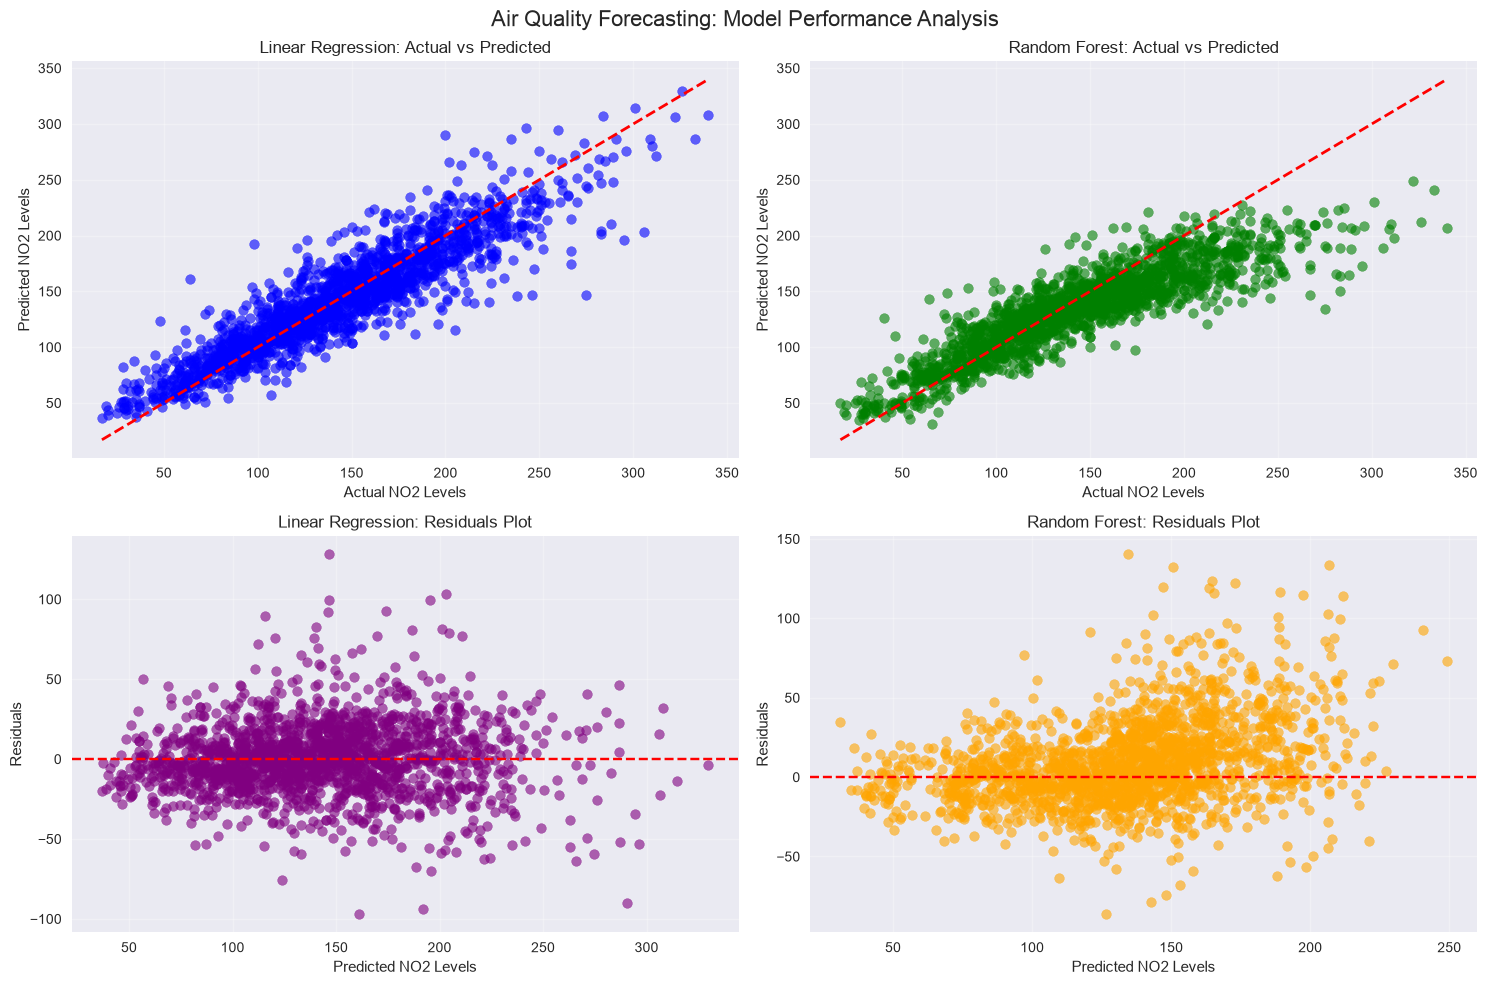

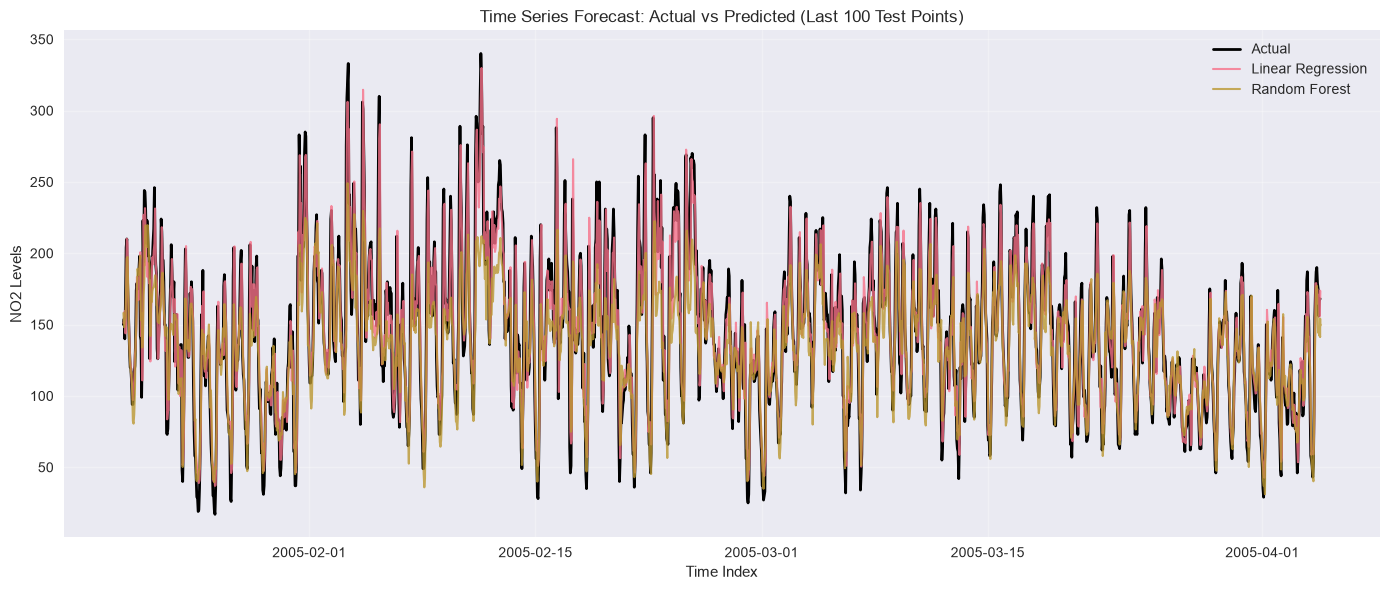

Visualization complete! Check the plots above for model performance insights.


In [24]:
# =============================================
# CELL 7: RESULTS VISUALIZATION
# =============================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Air Quality Forecasting: Model Performance Analysis', fontsize=16)

# Plot 1: Actual vs Predicted for Linear Regression
axes[0, 0].scatter(y_test, lr_pred, alpha=0.6, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual NO2 Levels')
axes[0, 0].set_ylabel('Predicted NO2 Levels')
axes[0, 0].set_title('Linear Regression: Actual vs Predicted')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted for Random Forest
axes[0, 1].scatter(y_test, rf_pred, alpha=0.6, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual NO2 Levels')
axes[0, 1].set_ylabel('Predicted NO2 Levels')
axes[0, 1].set_title('Random Forest: Actual vs Predicted')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals for Linear Regression
residuals_lr = y_test - lr_pred
axes[1, 0].scatter(lr_pred, residuals_lr, alpha=0.6, color='purple')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted NO2 Levels')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Linear Regression: Residuals Plot')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals for Random Forest
residuals_rf = y_test - rf_pred
axes[1, 1].scatter(rf_pred, residuals_rf, alpha=0.6, color='orange')
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted NO2 Levels')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Random Forest: Residuals Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 5: Time series comparison (last 100 points)
plt.figure(figsize=(14, 6))
test_indices = y_test.index
plt.plot(test_indices, y_test.values, label='Actual', color='black', linewidth=2)
plt.plot(test_indices, lr_pred, label='Linear Regression', alpha=0.8, linewidth=1.5)
plt.plot(test_indices, rf_pred, label='Random Forest', alpha=0.8, linewidth=1.5)
plt.xlabel('Time Index')
plt.ylabel('NO2 Levels')
plt.title('Time Series Forecast: Actual vs Predicted (Last 100 Test Points)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualization complete! Check the plots above for model performance insights.")

In [25]:
# =============================================
# CELL 8: FINAL ANALYSIS & INSIGHTS
# =============================================

print(" AIR QUALITY FORECASTING: FINAL ANALYSIS")
print("=" * 50)

# Key findings summary
print("\n KEY FINDINGS:")
print(f"• Best Performing Model: {best_model_name}")
print(f"• Prediction Accuracy (R²): {results_df['R²'].max():.4f}")
print(f"• Average Prediction Error (MAE): {results_df.loc[results_df['R²'].idxmax(), 'MAE']:.4f}")
print(f"• Root Mean Squared Error: {results_df.loc[results_df['R²'].idxmax(), 'RMSE']:.4f}")

# Feature importance (if using Random Forest)
if best_model_name == "Random Forest":
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTOP 5 MOST IMPORTANT FEATURES:")
    for idx, row in feature_importance.head().iterrows():
        print(f"• {row['feature']}: {row['importance']:.4f}")

# Model interpretation
print("\n MODEL INTERPRETATION:")
if results_df['R²'].max() > 0.7:
    print("• Strong predictive power - model explains >70% of variance")
elif results_df['R²'].max() > 0.4:
    print("• Moderate predictive power - model explains 40-70% of variance")
else:
    print("• Limited predictive power - consider feature engineering or more complex models")

print("\n IMPORTANT CONSIDERATIONS:")
print("• Time series forecasting requires careful validation (chronological split used)")
print("• External factors like weather, traffic patterns not included in this model")
print("• Model assumes recent patterns will continue - may not capture sudden changes")
print("• For production use, consider updating model regularly with new data")

print("\nTASK COMPLETION CHECKLIST:")
print("• [x] Data loading and inspection")
print("• [x] Missing value handling (-200 markers)")
print("• [x] Feature engineering (time features, lagged variables, rolling stats)")
print("• [x] Train/test split (chronological 80/20)")
print("• [x] Model training (Linear Regression & Random Forest)")
print("• [x] Model evaluation and comparison")
print("• [x] Results visualization")
print("• [x] Final analysis and insights")

print("\n AIR QUALITY FORECASTING TASK COMPLETE!")
print("Next: Proceed to MNIST Neural Network task (Task2_MNIST_NeuralNetwork)")

 AIR QUALITY FORECASTING: FINAL ANALYSIS

 KEY FINDINGS:
• Best Performing Model: Linear Regression
• Prediction Accuracy (R²): 0.8294
• Average Prediction Error (MAE): 15.5804
• Root Mean Squared Error: 21.7102

MODEL INTERPRETATION:
• Strong predictive power - model explains >70% of variance

 IMPORTANT CONSIDERATIONS:
• Time series forecasting requires careful validation (chronological split used)
• External factors like weather, traffic patterns not included in this model
• Model assumes recent patterns will continue - may not capture sudden changes
• For production use, consider updating model regularly with new data

TASK COMPLETION CHECKLIST:
• [x] Data loading and inspection
• [x] Missing value handling (-200 markers)
• [x] Feature engineering (time features, lagged variables, rolling stats)
• [x] Train/test split (chronological 80/20)
• [x] Model training (Linear Regression & Random Forest)
• [x] Model evaluation and comparison
• [x] Results visualization
• [x] Final analysis 